In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
df_full = pd.read_csv('US_Accidents_March23.csv', nrows=2)
print(df_full.columns.tolist())

['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']


In [47]:
cols_needed = [
    # Target variable
    'Severity',
    
    # Time
    'Start_Time',
    
    # Location (for heatmap)
    'Start_Lat', 'Start_Lng',
    'City', 'State',          # ← added: useful for top cities/states chart
    
    # Weather
    'Weather_Condition',
    'Temperature(F)',
    'Visibility(mi)',
    'Wind_Speed(mph)',         # ← added: extra weather insight
    'Humidity(%)',             # ← added: extra weather insight
    
    # Road conditions
    'Junction', 'Traffic_Signal', 'Crossing',
    'Bump', 'Stop', 'Railway',  # ← Railway added
    'Give_Way', 'Traffic_Calming',  # ← added
    
    # Day/Night
    'Sunrise_Sunset',
]

In [48]:
df = pd.read_csv('US_Accidents_March23.csv', usecols=cols_needed, nrows=500000)
print(df.shape)
df.head()

(500000, 20)


,Severity,Start_Time,Start_Lat,Start_Lng,City,State,Temperature(F),Humidity(%),Visibility(mi),Wind_Speed(mph),Weather_Condition,Bump,Crossing,Give_Way,Junction,Railway,Stop,Traffic_Calming,Traffic_Signal,Sunrise_Sunset
0,3,2016-02-08 05:46:00,39.865147,-84.058723,Dayton,OH,36.9,91.0,10.0,NaN,Light Rain,False,False,False,False,False,False,False,False,Night
1,2,2016-02-08 06:07:59,39.928059,-82.831184,Reynoldsburg,OH,37.9,100.0,10.0,NaN,Light Rain,False,False,False,False,False,False,False,False,Night
2,2,2016-02-08 06:49:27,39.063148,-84.032608,Williamsburg,OH,36.0,100.0,10.0,3.5,Overcast,False,False,False,False,False,False,False,True,Night
3,3,2016-02-08 07:23:34,39.747753,-84.205582,Dayton,OH,35.1,96.0,9.0,4.6,Mostly Cloudy,False,False,False,False,False,False,False,False,Night
4,2,2016-02-08 07:39:07,39.627781,-84.188354,Dayton,OH,36.0,89.0,6.0,3.5,Mostly Cloudy,False,False,False,False,False,False,False,True,Day


In [49]:
print(df.shape)
print("\nNull values:\n", df.isnull().sum())
print("\nSeverity distribution:\n", df['Severity'].value_counts())

(500000, 20)

Null values:
 Severity                 0
Start_Time               0
Start_Lat                0
Start_Lng                0
City                    22
State                    0
Temperature(F)        7250
Humidity(%)           7915
Visibility(mi)       10539
Wind_Speed(mph)      89040
Weather_Condition    10185
Bump                     0
Crossing                 0
Give_Way                 0
Junction                 0
Railway                  0
Stop                     0
Traffic_Calming          0
Traffic_Signal           0
Sunrise_Sunset          22
dtype: int64

Severity distribution:
 Severity
2    312159
3    187173
1       388
4       280
Name: count, dtype: int64


In [50]:
# Drop rows with nulls in critical columns
df.dropna(subset=['Start_Lat', 'Start_Lng', 'Severity', 'Weather_Condition'], inplace=True)

# Parse datetime and extract time features
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df['Hour'] = df['Start_Time'].dt.hour
df['Month'] = df['Start_Time'].dt.month
df['DayOfWeek'] = df['Start_Time'].dt.day_name()

print("After cleaning:", df.shape)

After cleaning: (489815, 23)


C:\Users\aishw\AppData\Local\Temp\ipykernel_14280\483589767.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Hour', data=df, palette='viridis')


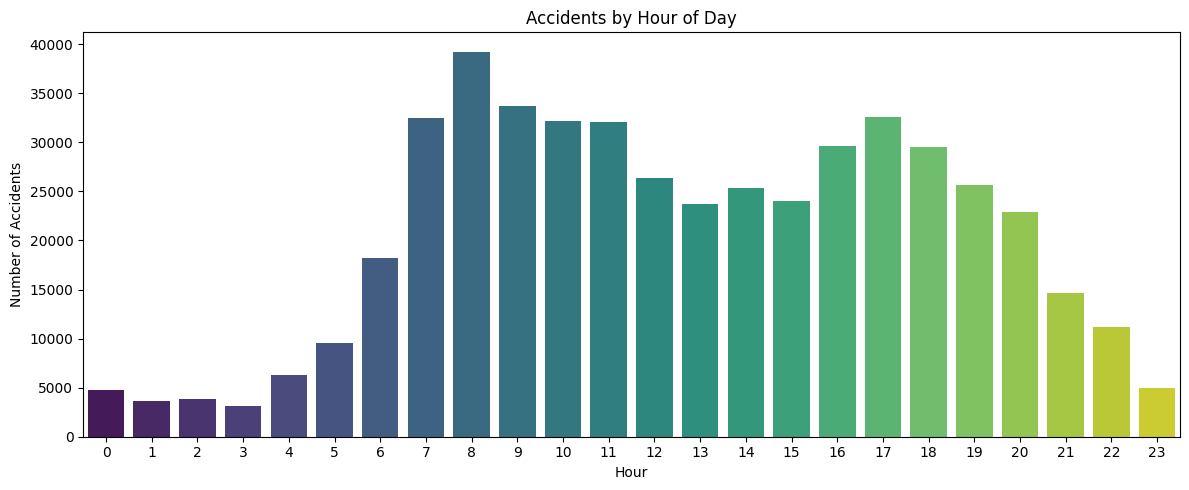

In [51]:
plt.figure(figsize=(12, 5))
sns.countplot(x='Hour', data=df, palette='viridis')
plt.title('Accidents by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Accidents')
plt.tight_layout()
plt.savefig('accidents_by_hour.png')
plt.show()

C:\Users\aishw\AppData\Local\Temp\ipykernel_14280\1817029545.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='DayOfWeek', data=df, order=order, palette='coolwarm')


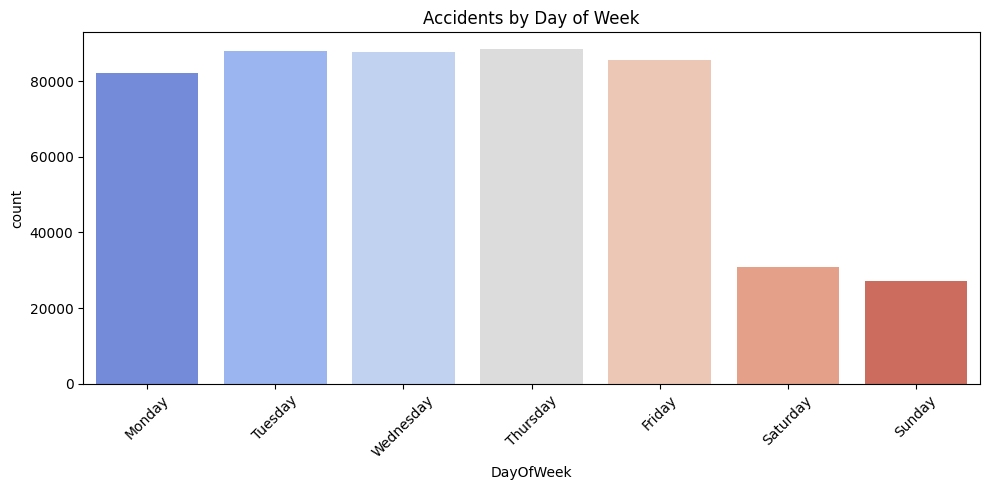

In [52]:
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
plt.figure(figsize=(10, 5))
sns.countplot(x='DayOfWeek', data=df, order=order, palette='coolwarm')
plt.title('Accidents by Day of Week')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('accidents_by_day.png')
plt.show()

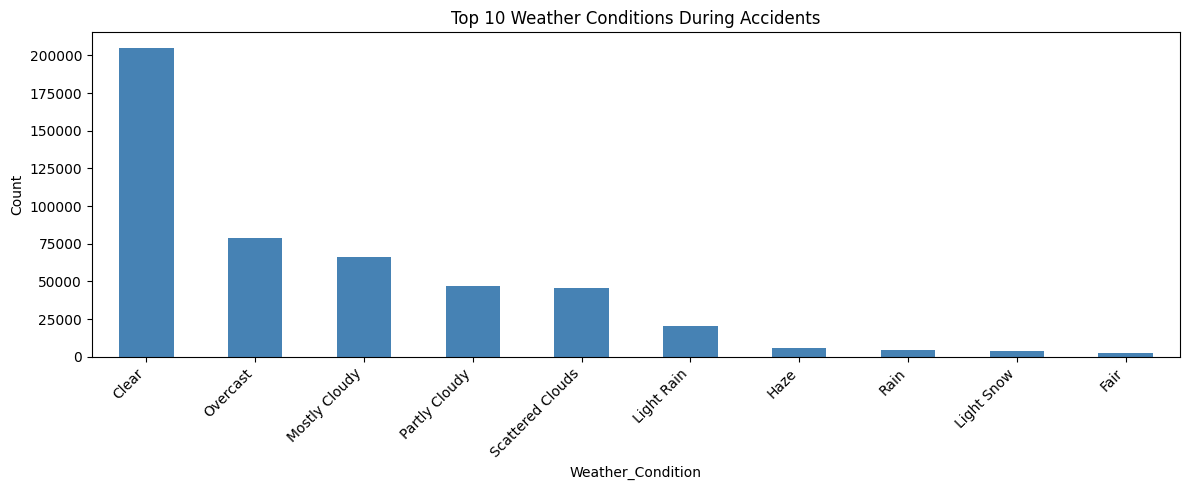

In [53]:
top_weather = df['Weather_Condition'].value_counts().head(10)
plt.figure(figsize=(12, 5))
top_weather.plot(kind='bar', color='steelblue')
plt.title('Top 10 Weather Conditions During Accidents')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('accidents_by_weather.png')
plt.show()

C:\Users\aishw\AppData\Local\Temp\ipykernel_14280\623851104.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Severity', data=df, palette='Reds')


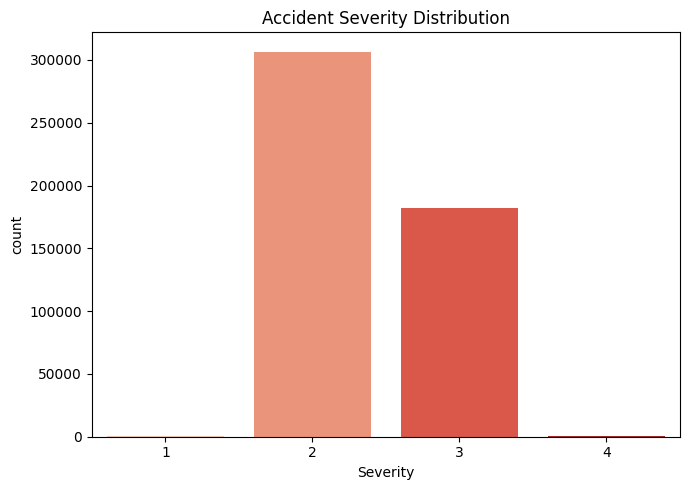

In [54]:
plt.figure(figsize=(7, 5))
sns.countplot(x='Severity', data=df, palette='Reds')
plt.title('Accident Severity Distribution')
plt.tight_layout()
plt.savefig('severity_distribution.png')
plt.show()

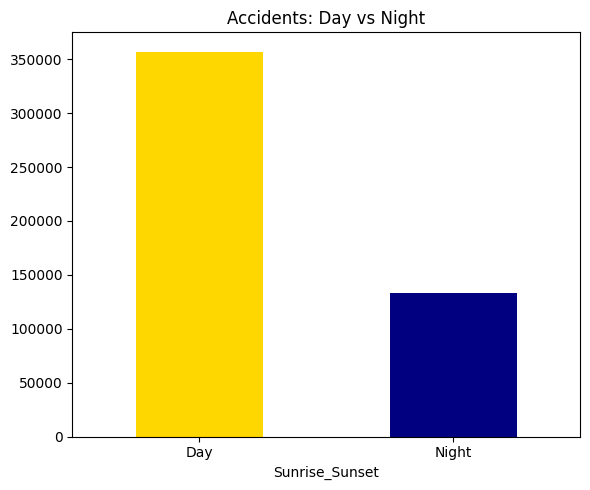

In [55]:
plt.figure(figsize=(6, 5))
df['Sunrise_Sunset'].value_counts().plot(kind='bar', color=['gold', 'navy'])
plt.title('Accidents: Day vs Night')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('day_vs_night.png')
plt.show()

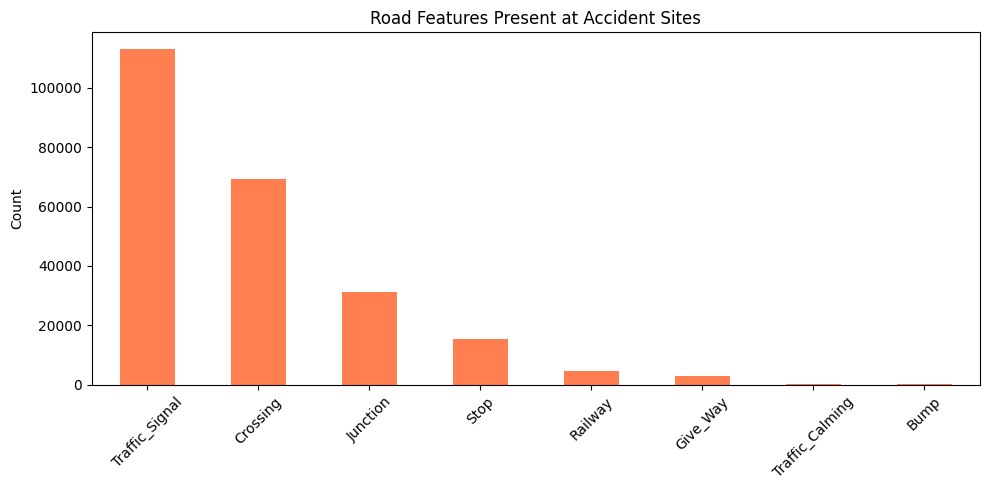

In [56]:
road_features = ['Junction', 'Traffic_Signal', 'Crossing', 
                 'Bump', 'Stop', 'Railway', 'Give_Way', 'Traffic_Calming']
road_counts = df[road_features].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
road_counts.plot(kind='bar', color='coral')
plt.title('Road Features Present at Accident Sites')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('road_features.png')
plt.show()

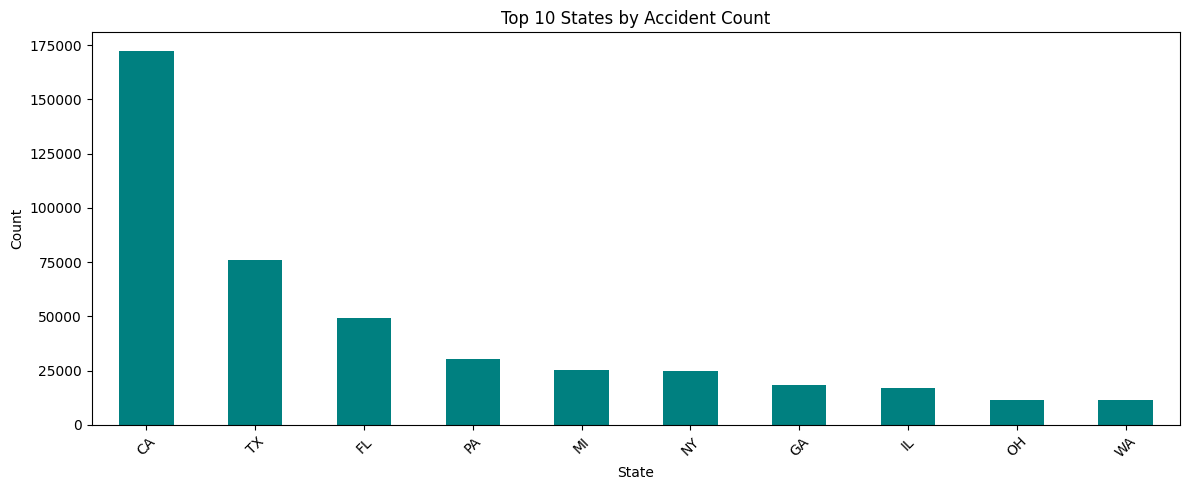

In [57]:
plt.figure(figsize=(12, 5))
df['State'].value_counts().head(10).plot(kind='bar', color='teal')
plt.title('Top 10 States by Accident Count')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top_states.png')
plt.show()

In [58]:
# pip install folium  ← run in terminal if not installed

import folium
from folium.plugins import HeatMap

sample = df[['Start_Lat', 'Start_Lng']].dropna().sample(50000, random_state=42)

m = folium.Map(location=[37.09, -95.71], zoom_start=4)
HeatMap(data=sample.values.tolist(), radius=8).add_to(m)
m.save('accident_hotspot_map.html')
print("✅ Heatmap saved as accident_hotspot_map.html")

✅ Heatmap saved as accident_hotspot_map.html


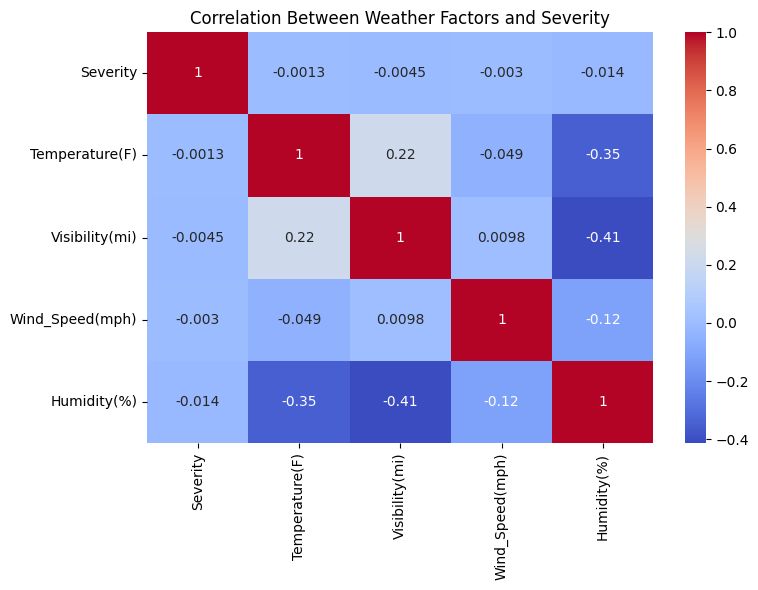

In [59]:
plt.figure(figsize=(8,6))
num_cols = ['Severity','Temperature(F)','Visibility(mi)','Wind_Speed(mph)','Humidity(%)']
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between Weather Factors and Severity')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

C:\Users\aishw\AppData\Local\Temp\ipykernel_14280\1468386221.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Month', data=df, palette='Blues')


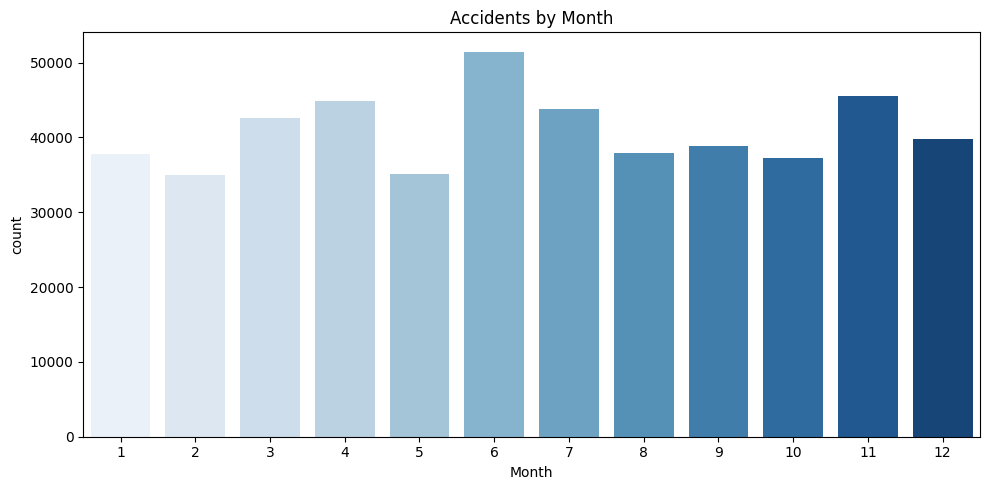

In [60]:
plt.figure(figsize=(10,5))
sns.countplot(x='Month', data=df, palette='Blues')
plt.title('Accidents by Month')
plt.tight_layout()
plt.savefig('accidents_by_month.png')
plt.show()